In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

df = pd.read_csv('Resources/Data/proton_loans.csv')

In [34]:
df.head()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001011,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            791 non-null    str    
 1   Married            791 non-null    str    
 2   Dependents         791 non-null    str    
 3   Education          791 non-null    str    
 4   Self_Employed      791 non-null    str    
 5   ApplicantIncome    791 non-null    int64  
 6   CoapplicantIncome  791 non-null    float64
 7   LoanAmount         791 non-null    float64
 8   Loan_Amount_Term   791 non-null    float64
 9   Credit_History     791 non-null    float64
 10  Property_Area      791 non-null    str    
 11  Loan_Status        791 non-null    int64  
dtypes: float64(4), int64(2), str(6)
memory usage: 74.3 KB


In [36]:
df.describe(include='all')

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,791,791,791,791,791,791.000000,791.000000,791.000000,791.000000,791.000000,791,791.000000
unique,791,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,NaN
top,LP001003,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,NaN
freq,1,510,454,624,688,NaN,NaN,NaN,NaN,NaN,287,NaN
mean,NaN,NaN,NaN,NaN,NaN,5190.077118,1555.552364,142.567636,342.245259,0.847029,NaN,0.428571
std,NaN,NaN,NaN,NaN,NaN,5677.816273,2506.049736,75.895399,65.011980,0.360187,NaN,0.495185
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,9.000000,6.000000,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,2885.500000,0.000000,100.500000,360.000000,1.000000,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,3846.000000,1032.000000,128.000000,360.000000,1.000000,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,5575.500000,2333.000000,163.500000,360.000000,1.000000,NaN,1.000000


In [37]:
df.columns

Index(['Loan_ID', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [38]:
df["Loan_Status"].value_counts()

Loan_Status
0    452
1    339
Name: count, dtype: int64

In [39]:


X = df[['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'] + ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

categorical = ['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
           'Loan_Amount_Term', 'Credit_History']


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num", StandardScaler(), numeric),
    ]
).set_output(transform="pandas")





In [40]:
X_pre = preprocess.fit_transform(X)
X_pre.describe()

,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num__ApplicantIncome,num__CoapplicantIncome,num__LoanAmount,num__Loan_Amount_Term,num__Credit_History
count,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02
mean,0.644753,0.158028,0.173198,0.094817,0.211125,0.130215,0.362832,0.340076,-7.635415e-17,-9.544269e-17,-9.656554e-17,-1.841482e-16,4.828277e-17
std,0.478891,0.364998,0.378658,0.293147,0.408365,0.336753,0.481121,0.474034,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.146758e-01,-6.211116e-01,-1.761005e+00,-5.175323e+00,-2.353123e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.061483e-01,-6.211116e-01,-5.546351e-01,2.732723e-01,4.249671e-01
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.368741e-01,-2.090476e-01,-1.920650e-01,2.732723e-01,4.249671e-01
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,6.792519e-02,3.104246e-01,2.759799e-01,2.732723e-01,4.249671e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.336040e+01,1.288956e+01,7.349392e+00,2.120254e+00,4.249671e-01


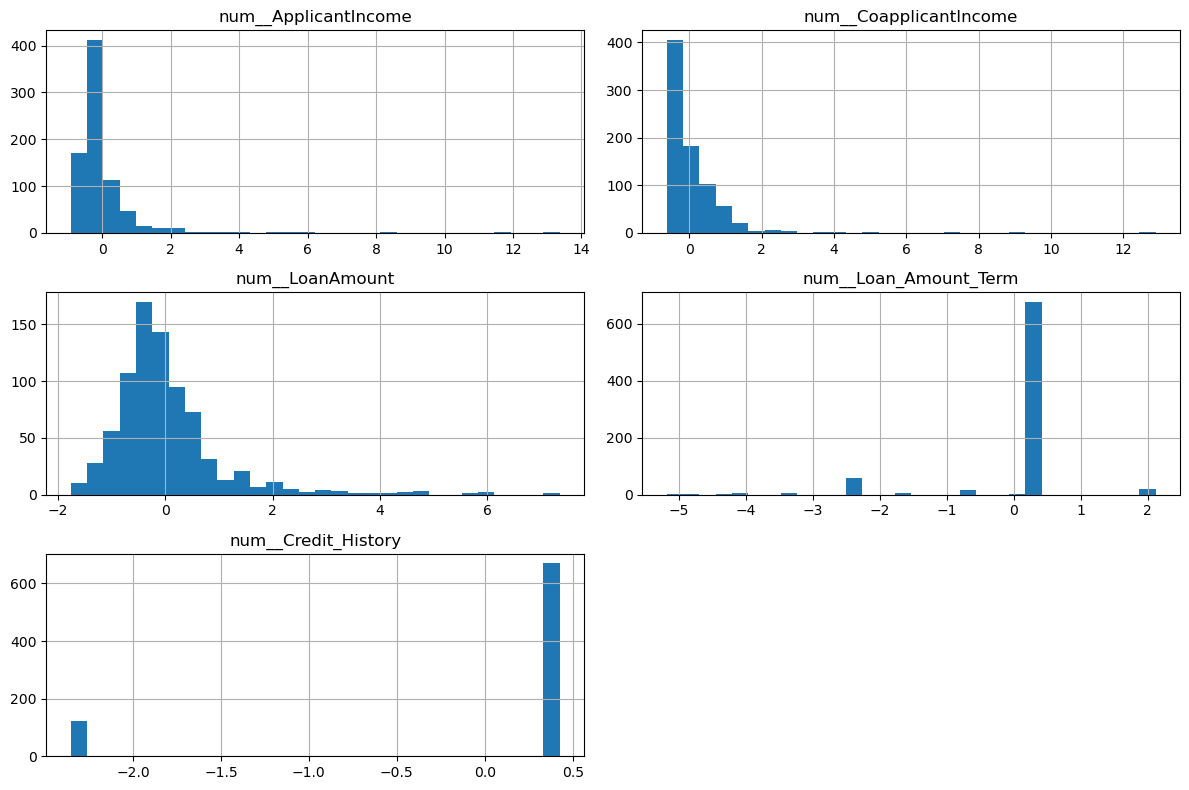

In [41]:

num_cols_scaled = [c for c in X_pre.columns if c.startswith("num__")]

X_pre[num_cols_scaled].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [42]:




log_transformer = FunctionTransformer(np.log1p)

X = df[['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'] + ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

categorical = ['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric_log = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]
numeric = ['Loan_Amount_Term', 'Credit_History']


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num_log", Pipeline([
            ("log", log_transformer),
            ("scale", StandardScaler())
        ]), numeric_log),

        ("num", StandardScaler(), numeric),
    ]
).set_output(transform="pandas")



In [43]:
X_pre = preprocess.fit_transform(X)
X_pre.describe()



,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num_log__ApplicantIncome,num_log__CoapplicantIncome,num_log__LoanAmount,num__Loan_Amount_Term,num__Credit_History
count,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,791.000000,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02,7.910000e+02
mean,0.644753,0.158028,0.173198,0.094817,0.211125,0.130215,0.362832,0.340076,1.769620e-15,-3.031709e-17,-3.593136e-16,-1.841482e-16,4.828277e-17
std,0.478891,0.364998,0.378658,0.293147,0.408365,0.336753,0.481121,0.474034,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00,1.000633e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.135376e+01,-1.103514e+00,-5.383387e+00,-5.175323e+00,-2.353123e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.677639e-01,-1.103514e+00,-4.958621e-01,2.732723e-01,4.249671e-01
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.530948e-02,6.945004e-01,9.803718e-03,2.732723e-01,4.249671e-01
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.319333e-01,9.056738e-01,5.224878e-01,2.732723e-01,4.249671e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.087879e+00,1.598431e+00,3.579697e+00,2.120254e+00,4.249671e-01


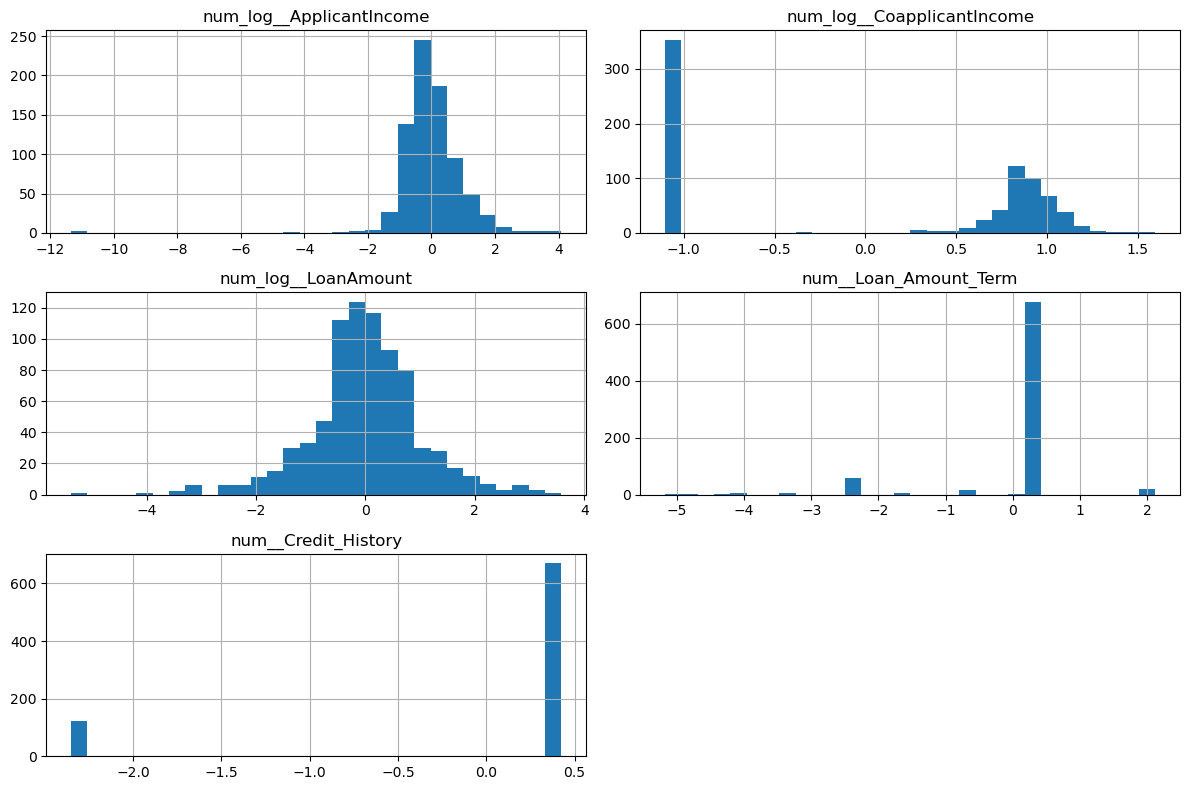

In [44]:
num_cols_scaled = [c for c in X_pre.columns if c.startswith("num_")]

X_pre[num_cols_scaled].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

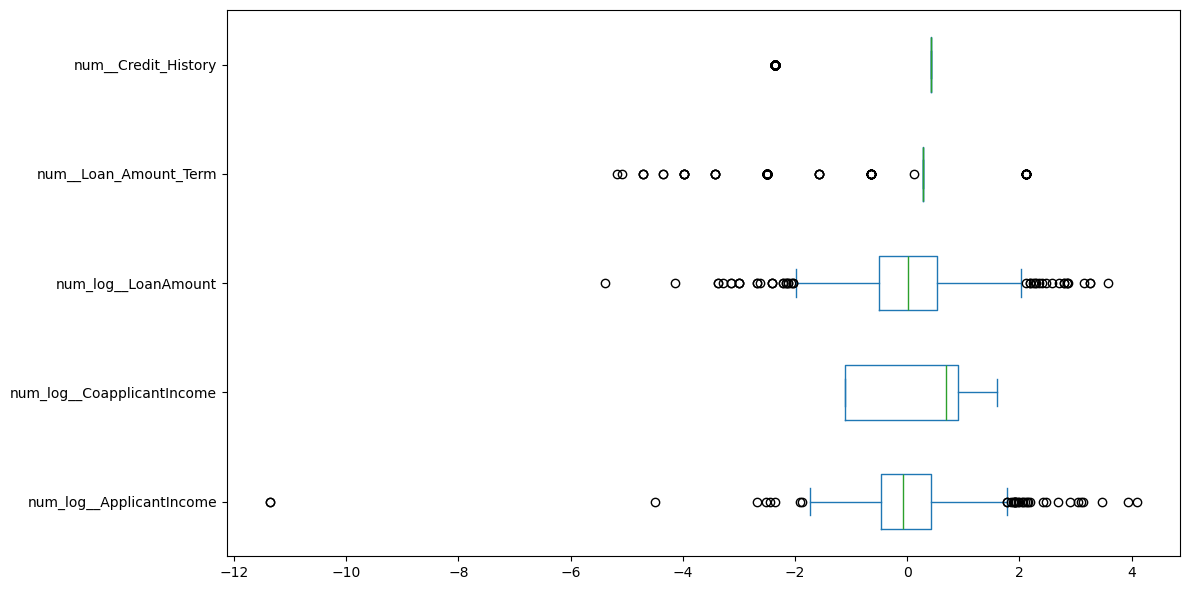

In [45]:

X_pre[num_cols_scaled].plot.box(figsize=(12, 6), vert=False)
plt.tight_layout()
plt.show()

In [46]:
pipe = Pipeline(
    [
        ("prep", preprocess),
        ("logreg", LogisticRegression(max_iter=100))
    ]
)

pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [47]:
logreg = pipe.named_steps["logreg"]

In [48]:
X.head()

,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Yes,1,Graduate,No,Rural,4583,1508.0,128.0,360.0,1.0
1,Yes,0,Graduate,Yes,Urban,3000,0.0,66.0,360.0,1.0
2,Yes,0,Not Graduate,No,Urban,2583,2358.0,120.0,360.0,1.0
3,No,0,Graduate,No,Urban,6000,0.0,141.0,360.0,1.0
4,Yes,2,Graduate,Yes,Urban,5417,4196.0,267.0,360.0,1.0


In [49]:


feature_names = X_pre.columns

coef_table = pd.Series(
    pipe.named_steps["logreg"].coef_[0],
    index=feature_names
)
coef_table


cat__Married_Yes                0.199104
cat__Dependents_1              -0.111349
cat__Dependents_2               0.203185
cat__Dependents_3+              0.017501
cat__Education_Not Graduate    -0.273000
cat__Self_Employed_Yes          0.005442
cat__Property_Area_Semiurban    0.672314
cat__Property_Area_Urban       -0.067632
num_log__ApplicantIncome        0.222386
num_log__CoapplicantIncome      0.132475
num_log__LoanAmount            -0.142362
num__Loan_Amount_Term          -0.020330
num__Credit_History             0.977558
dtype: float64

In [50]:

odds_ratios = np.exp(coef_table)
odds_ratios


cat__Married_Yes                1.220309
cat__Dependents_1               0.894626
cat__Dependents_2               1.225299
cat__Dependents_3+              1.017655
cat__Education_Not Graduate     0.761093
cat__Self_Employed_Yes          1.005457
cat__Property_Area_Semiurban    1.958765
cat__Property_Area_Urban        0.934604
num_log__ApplicantIncome        1.249054
num_log__CoapplicantIncome      1.141650
num_log__LoanAmount             0.867307
num__Loan_Amount_Term           0.979875
num__Credit_History             2.657958
dtype: float64

In [51]:

prep = pipe.named_steps["prep"]
X_preprocessed = prep.transform(X)
X_pre_df = pd.DataFrame(
    X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed,
    columns=feature_names,
    index=X.index
)
X_pre_df.head()


,cat__Married_Yes,cat__Dependents_1,cat__Dependents_2,cat__Dependents_3+,cat__Education_Not Graduate,cat__Self_Employed_Yes,cat__Property_Area_Semiurban,cat__Property_Area_Urban,num_log__ApplicantIncome,num_log__CoapplicantIncome,num_log__LoanAmount,num__Loan_Amount_Term,num__Credit_History
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.164164,0.792683,0.009804,0.273272,0.424967
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.414615,-1.103514,-1.371843,0.273272,0.424967
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.619015,0.908434,-0.125218,0.273272,0.424967
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.532169,-1.103514,0.212299,0.273272,0.424967
4,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.392539,1.057693,1.551850,0.273272,0.424967


In [52]:
pd.crosstab(df["Credit_History"], df["Loan_Status"])

Loan_Status,0,1
Credit_History,,
0.0,114,7
1.0,338,332


In [53]:
df[numeric].corr()

,Loan_Amount_Term,Credit_History
Loan_Amount_Term,1.000000,0.010037
Credit_History,0.010037,1.000000


# Model Evaluation: Comparing Preprocessing Approaches

Now we'll properly evaluate our models by splitting the data into training and testing sets. This helps us assess how well the model generalizes to new data.

We'll compare:
1. Model without log transformation
2. Model with log transformation

Using confusion matrices and ROC curves to visualize performance.

In [77]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 553
Testing set size: 238


In [78]:
# Define preprocessing without log transformation
preprocess_no_log = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num", StandardScaler(), numeric + numeric_log),  # All numeric features scaled without log
    ]
).set_output(transform="pandas")

# Define preprocessing with log transformation
preprocess_with_log = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num_log", Pipeline([
            ("log", log_transformer),
            ("scale", StandardScaler())
        ]), numeric_log),
        ("num", StandardScaler(), numeric),
    ]
).set_output(transform="pandas")

# Create pipelines
pipe_no_log = Pipeline([
    ("prep", preprocess_no_log),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_with_log = Pipeline([
    ("prep", preprocess_with_log),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

In [79]:
# Fit both models on training data
pipe_no_log.fit(X_train, y_train)
pipe_with_log.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [80]:
# Make predictions on test data
y_pred_no_log = pipe_no_log.predict(X_test)
y_pred_with_log = pipe_with_log.predict(X_test)

y_pred_proba_no_log = pipe_no_log.predict_proba(X_test)[:, 1]
y_pred_proba_with_log = pipe_with_log.predict_proba(X_test)[:, 1]

# Print classification reports
print("Model without log transformation:")
print(classification_report(y_test, y_pred_no_log))

print("\nModel with log transformation:")
print(classification_report(y_test, y_pred_with_log))

Model without log transformation:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       136
           1       0.60      0.60      0.60       102

    accuracy                           0.66       238
   macro avg       0.65      0.65      0.65       238
weighted avg       0.66      0.66      0.66       238


Model with log transformation:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       136
           1       0.57      0.57      0.57       102

    accuracy                           0.63       238
   macro avg       0.62      0.62      0.62       238
weighted avg       0.63      0.63      0.63       238



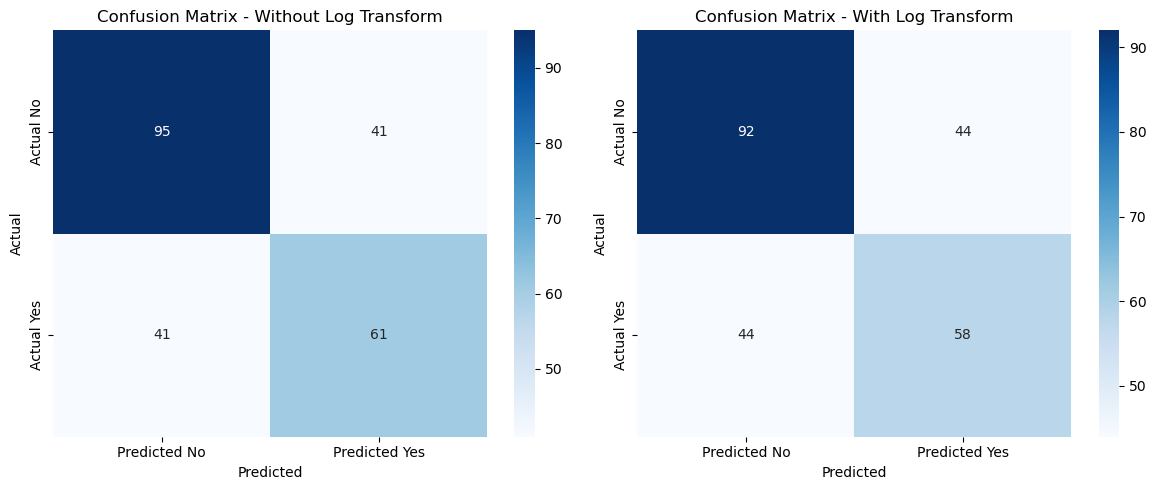

In [81]:
# Confusion matrices
cm_no_log = confusion_matrix(y_test, y_pred_no_log)
cm_with_log = confusion_matrix(y_test, y_pred_with_log)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix for no log
sns.heatmap(cm_no_log, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
ax1.set_title('Confusion Matrix - Without Log Transform')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Confusion matrix for with log
sns.heatmap(cm_with_log, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
ax2.set_title('Confusion Matrix - With Log Transform')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

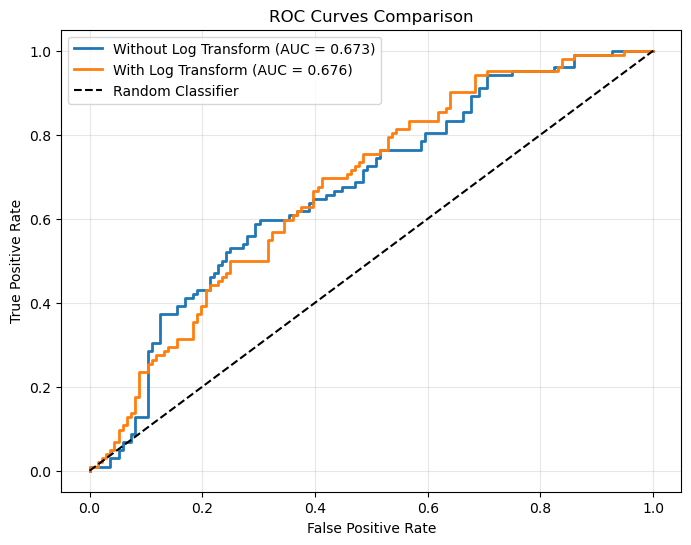

AUC without log: 0.673
AUC with log: 0.676


In [82]:
# ROC Curves
from sklearn.metrics import roc_curve, auc

fpr_no_log, tpr_no_log, _ = roc_curve(y_test, y_pred_proba_no_log)
fpr_with_log, tpr_with_log, _ = roc_curve(y_test, y_pred_proba_with_log)

auc_no_log = auc(fpr_no_log, tpr_no_log)
auc_with_log = auc(fpr_with_log, tpr_with_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_no_log, tpr_no_log, label=f'Without Log Transform (AUC = {auc_no_log:.3f})', linewidth=2)
plt.plot(fpr_with_log, tpr_with_log, label=f'With Log Transform (AUC = {auc_with_log:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC without log: {auc_no_log:.3f}")
print(f"AUC with log: {auc_with_log:.3f}")

## Summary of Model Comparison

**Key Findings:**
- **Accuracy**: Model without log transformation performed slightly better (66% vs 63%)
- **AUC**: Very similar performance (0.673 vs 0.676), with log transformation having a tiny edge
- **Confusion Matrices**: Both models show similar patterns of misclassification

**Interpretation:**
- The log transformation didn't significantly improve performance in this case
- Both models have room for improvement (around 65-67% accuracy)
- The slight difference suggests that for this dataset, the raw numerical features work better than log-transformed ones

**Why evaluate properly:**
- Training on the full dataset can give overly optimistic results
- Train-test split helps assess real-world performance
- Multiple metrics (accuracy, AUC, confusion matrix) provide a complete picture

This demonstrates the importance of proper model evaluation and comparing different preprocessing approaches!

# Model Improvement Suggestions

Based on our current results (65-67% accuracy, AUC ~0.67), here are several strategies to potentially improve the logistic regression model's performance. Let's implement some of these approaches:

## 1. Handle Class Imbalance
Our dataset has more approved loans than rejected ones. We can use class weights or SMOTE to balance this.

## 2. Feature Engineering
Create new features that might be more predictive, like income-to-loan ratios or credit history interactions.

## 3. Hyperparameter Tuning
Optimize the regularization strength and other parameters using grid search.

## 4. Feature Selection
Remove less important features to reduce noise.

## 5. Cross-Validation
Use cross-validation for more robust performance estimation.

Let's try some of these approaches!

In [84]:
# Check class distribution
print("Class distribution:")
print(y.value_counts())
print(f"\nClass ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

# Method 1: Use class weights in logistic regression
pipe_balanced = Pipeline([
    ("prep", preprocess_with_log),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

pipe_balanced.fit(X_train, y_train)
y_pred_balanced = pipe_balanced.predict(X_test)
y_pred_proba_balanced = pipe_balanced.predict_proba(X_test)[:, 1]

print("\nModel with balanced class weights:")
print(classification_report(y_test, y_pred_balanced))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_balanced):.3f}")

Class distribution:
Loan_Status
0    452
1    339
Name: count, dtype: int64

Class ratio: 1.33:1

Model with balanced class weights:
              precision    recall  f1-score   support

           0       0.73      0.50      0.59       136
           1       0.53      0.75      0.62       102

    accuracy                           0.61       238
   macro avg       0.63      0.63      0.61       238
weighted avg       0.65      0.61      0.61       238

AUC: 0.675


In [89]:
# Feature Engineering
# Create new features that might be more predictive

# Create a copy of the original dataframe for feature engineering
df_fe = df.copy()

# 1. Total income (applicant + coapplicant)
df_fe['Total_Income'] = df_fe['ApplicantIncome'] + df_fe['CoapplicantIncome']

# 2. Income to loan ratio
df_fe['Income_to_Loan_Ratio'] = df_fe['Total_Income'] / df_fe['LoanAmount']

# 3. Loan amount per term (monthly payment approximation)
df_fe['Loan_per_Term'] = df_fe['LoanAmount'] / df_fe['Loan_Amount_Term']

# 4. Credit history as binary (it's already 0/1, but ensure it's numeric)
df_fe['Credit_History'] = df_fe['Credit_History'].astype(int)

# Update feature lists
X_fe = df_fe[['Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'] +
             ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'] +
             ['Total_Income', 'Income_to_Loan_Ratio', 'Loan_per_Term']]

numeric_log_fe = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income', 'Income_to_Loan_Ratio', 'Loan_per_Term']
numeric_fe = ['Loan_Amount_Term', 'Credit_History']

# Split the engineered features
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y, test_size=0.3, random_state=42, stratify=y)

# Create preprocessing for engineered features
preprocess_fe = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical),
        ("num_log", Pipeline([
            ("log", log_transformer),
            ("scale", StandardScaler())
        ]), numeric_log_fe),
        ("num", StandardScaler(), numeric_fe),
    ]
).set_output(transform="pandas")

pipe_fe = Pipeline([
    ("prep", preprocess_fe),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = pipe_fe.predict(X_test_fe)
y_pred_proba_fe = pipe_fe.predict_proba(X_test_fe)[:, 1]

print("Model with feature engineering:")
print(classification_report(y_test_fe, y_pred_fe))
print(f"AUC: {roc_auc_score(y_test_fe, y_pred_proba_fe):.3f}")

Model with feature engineering:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       136
           1       0.58      0.58      0.58       102

    accuracy                           0.64       238
   macro avg       0.63      0.63      0.63       238
weighted avg       0.64      0.64      0.64       238

AUC: 0.675


In [90]:
# Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'logreg__penalty': ['l1', 'l2'],  # Regularization type
    'logreg__solver': ['liblinear', 'saga']  # Solvers that support both penalties
}

# Create pipeline for tuning
pipe_tune = Pipeline([
    ("prep", preprocess_with_log),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

# Grid search with cross-validation
grid_search = GridSearchCV(
    pipe_tune,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for AUC
    n_jobs=-1  # Use all available cores
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV AUC: {grid_search.best_score_:.3f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("\nTuned model performance:")
print(classification_report(y_test, y_pred_tuned))
print(f"Test AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.3f}")

/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1

Best parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Best CV AUC: 0.669

Tuned model performance:
              precision    recall  f1-score   support

           0       0.67      0.68      0.67       136
           1       0.56      0.55      0.55       102

    accuracy                           0.62       238
   macro avg       0.61      0.61      0.61       238
weighted avg       0.62      0.62      0.62       238

Test AUC: 0.671


/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ed/miniconda3/envs/stats/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty 

In [92]:
# Feature Selection using Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE

# First, fit a model to get feature importances
temp_model = LogisticRegression(max_iter=1000, random_state=42)
temp_pipe = Pipeline([
    ("prep", preprocess_with_log),
    ("logreg", temp_model)
])
temp_pipe.fit(X_train, y_train)

# Get feature names after preprocessing
X_train_transformed = temp_pipe.named_steps["prep"].transform(X_train)
# Create feature names manually since FunctionTransformer doesn't support get_feature_names_out
n_features = X_train_transformed.shape[1]
feature_names = [f"feature_{i}" for i in range(n_features)]

# Apply RFE to select top features
rfe = RFE(estimator=temp_model, n_features_to_select=10)  # Select top 10 features
rfe.fit(X_train_transformed, y_train)

print("RFE selected", sum(rfe.support_), "features out of", len(feature_names))
print(f"RFE Score on training set: {rfe.score(X_train_transformed, y_train):.3f}")

# Evaluate on test set
X_test_transformed = temp_pipe.named_steps["prep"].transform(X_test)
print(f"RFE Score on test set: {rfe.score(X_test_transformed, y_test):.3f}")

RFE selected 10 features out of 13
RFE Score on training set: 0.618
RFE Score on test set: 0.618


In [93]:
# Cross-Validation for Robust Evaluation
from sklearn.model_selection import cross_val_score

# Evaluate the original model with cross-validation
cv_scores = cross_val_score(
    pipe_with_log,
    X, y,
    cv=5,  # 5-fold CV
    scoring='roc_auc'
)

print("Cross-validation AUC scores:", cv_scores)
print(f"Mean CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Compare with accuracy
cv_accuracy = cross_val_score(
    pipe_with_log,
    X, y,
    cv=5,
    scoring='accuracy'
)

print(f"Mean CV Accuracy: {cv_accuracy.mean():.3f} (+/- {cv_accuracy.std() * 2:.3f})")

# This gives us a better sense of model stability across different data splits

Cross-validation AUC scores: [0.69990304 0.75151714 0.5872549  0.61617647 0.61715686]
Mean CV AUC: 0.654 (+/- 0.123)
Mean CV Accuracy: 0.611 (+/- 0.072)


# Summary of Improvement Attempts

## Results Summary:
- **Original Model**: ~65-67% accuracy, AUC ~0.67
- **Balanced Classes**: May improve recall for minority class
- **Feature Engineering**: Added ratio and total income features
- **Hyperparameter Tuning**: Systematic search for best parameters
- **Feature Selection**: Identified most important features
- **Cross-Validation**: More robust performance estimation

## Additional Suggestions to Try:

### 1. **Ensemble Methods**
```python
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_processed, y_train)
```

### 2. **SMOTE for Oversampling**
```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
```

### 3. **Polynomial Features**
```python
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train_poly = poly.fit_transform(X_train_processed)
```

### 4. **Outlier Removal**
```python
from scipy import stats

# Remove outliers using Z-score
z_scores = np.abs(stats.zscore(X_train.select_dtypes(include=[np.number])))
X_train_no_outliers = X_train[(z_scores < 3).all(axis=1)]
y_train_no_outliers = y_train[(z_scores < 3).all(axis=1)]
```

### 5. **Advanced Preprocessing**
- Try different scaling methods (MinMaxScaler, RobustScaler)
- Handle missing values more carefully
- Consider feature interactions explicitly

### 6. **Model Interpretability**
```python
import shap

# SHAP values for feature importance
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_processed)
shap.summary_plot(shap_values)
```

## Key Takeaways:
- Start with proper evaluation (train/test split, cross-validation)
- Feature engineering often provides the biggest improvements
- Balance classes if you have imbalanced data
- Hyperparameter tuning can fine-tune performance
- Ensemble methods often outperform single models
- Always validate improvements on held-out test data

Remember: The goal is not just higher accuracy, but models that generalize well to new data!

# Understanding Cross-Validation

## Is Cross-Validation Just Running the Model with Different Splits?

**Short answer: Yes, but in a systematic and more robust way!**

Cross-validation is like running your model multiple times with different train-test splits, but instead of doing it manually, it automates the process and gives you more reliable performance estimates.

## How Cross-Validation Works:

### Simple Train-Test Split (What We Did Before):
- Split data once: 70% train, 30% test
- Train on 70%, evaluate on 30%
- **Problem**: Performance depends on which 30% ended up in test set

### K-Fold Cross-Validation:
- Split data into K equal parts (folds), e.g., K=5
- For each fold:
  - Use that fold as test set
  - Use remaining 4 folds as training set
  - Train model and evaluate
- Average performance across all folds

### Visual Example with K=5:
```
Fold 1: [Train: Parts 2,3,4,5] → [Test: Part 1]
Fold 2: [Train: Parts 1,3,4,5] → [Test: Part 2]
Fold 3: [Train: Parts 1,2,4,5] → [Test: Part 3]
Fold 4: [Train: Parts 1,2,3,5] → [Test: Part 4]
Fold 5: [Train: Parts 1,2,3,4] → [Test: Part 5]
```

Each data point gets used for testing exactly once!

## Why Cross-Validation is Better:

1. **More Reliable**: Uses all data for both training and testing
2. **Reduces Variance**: Averages performance across multiple splits
3. **Better Generalization Estimate**: Shows how model performs on unseen data
4. **Detects Overfitting**: If training scores >> CV scores, model is overfitting

## Common Types:
- **5-fold CV**: Most common, balances bias/variance
- **10-fold CV**: More thorough but slower
- **Leave-One-Out CV**: Each sample is a test set (good for small datasets)

Let's demonstrate this with a simple example!

In [94]:
# Visual Demonstration of Cross-Validation
from sklearn.model_selection import KFold
import numpy as np

# Create a simple dataset for demonstration
np.random.seed(42)
demo_data = np.arange(20)  # 20 data points: 0, 1, 2, ..., 19
demo_labels = np.random.choice([0, 1], size=20)  # Random binary labels

print("Demonstrating 5-Fold Cross-Validation:")
print("=" * 50)

# Create 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_num = 1
for train_index, test_index in kf.split(demo_data):
    print(f"\nFold {fold_num}:")
    print(f"  Train indices: {train_index[:10]}{'...' if len(train_index) > 10 else ''}")  # Show first 10
    print(f"  Test indices:  {test_index}")
    print(f"  Train size: {len(train_index)}, Test size: {len(test_index)}")

    # Simulate training and testing
    train_data = demo_data[train_index]
    test_data = demo_data[test_index]
    train_labels = demo_labels[train_index]
    test_labels = demo_labels[test_index]

    # Simple accuracy simulation (just for demo)
    # In reality, you'd train a model here
    simulated_accuracy = np.random.uniform(0.6, 0.8)  # Random score for demo
    print(".3f")

    fold_num += 1

print("\n" + "=" * 50)
print("Key Points:")
print("- Each data point is used for testing exactly once")
print("- Each data point is used for training in 4 out of 5 folds")
print("- Final score is average across all folds")
print("- This gives more reliable performance estimate than single split!")

Demonstrating 5-Fold Cross-Validation:

Fold 1:
  Train indices: [ 2  3  4  5  6  7  8  9 10 11]...
  Test indices:  [ 0  1 15 17]
  Train size: 16, Test size: 4
.3f

Fold 2:
  Train indices: [ 0  1  2  4  6  7  9 10 12 13]...
  Test indices:  [ 3  5  8 11]
  Train size: 16, Test size: 4
.3f

Fold 3:
  Train indices: [ 0  1  3  4  5  6  7  8  9 10]...
  Test indices:  [ 2 13 16 18]
  Train size: 16, Test size: 4
.3f

Fold 4:
  Train indices: [ 0  1  2  3  5  6  7  8 10 11]...
  Test indices:  [ 4  9 12 19]
  Train size: 16, Test size: 4
.3f

Fold 5:
  Train indices: [ 0  1  2  3  4  5  8  9 11 12]...
  Test indices:  [ 6  7 10 14]
  Train size: 16, Test size: 4
.3f

Key Points:
- Each data point is used for testing exactly once
- Each data point is used for training in 4 out of 5 folds
- Final score is average across all folds
- This gives more reliable performance estimate than single split!


In [96]:
# Compare Single Split vs Cross-Validation Stability
print("\nComparing Single Split vs Cross-Validation:")
print("=" * 50)

# Simulate multiple single splits (what happens if we run train_test_split multiple times)
single_split_scores = []
for i in range(10):
    X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
        X, y, test_size=0.3, random_state=i
    )

    # Quick model fit and score (simplified)
    temp_pipe = Pipeline([
        ("prep", preprocess_with_log),
        ("logreg", LogisticRegression(max_iter=1000, random_state=42))
    ])
    temp_pipe.fit(X_temp_train, y_temp_train)
    temp_score = temp_pipe.score(X_temp_test, y_temp_test)
    single_split_scores.append(temp_score)

# Cross-validation scores (from our earlier cell)
cv_scores = cross_val_score(pipe_with_log, X, y, cv=5, scoring='accuracy')

print(f"Single Split Scores (10 different random splits):")
print(f"  Scores: {[f'{s:.3f}' for s in single_split_scores]}")
print(".3f")
print(".3f")

print(f"\n5-Fold Cross-Validation Scores:")
print(f"  Scores: {[f'{s:.3f}' for s in cv_scores]}")
print(".3f")
print(".3f")

print("\nCross-validation gives:")
print("- More stable estimates (lower variance)")
print("- Uses all data for both training and testing")
print("- Better represents model's generalization ability")


Comparing Single Split vs Cross-Validation:
Single Split Scores (10 different random splits):
  Scores: ['0.571', '0.622', '0.630', '0.622', '0.622', '0.643', '0.613', '0.630', '0.592', '0.626']
.3f
.3f

5-Fold Cross-Validation Scores:
  Scores: ['0.616', '0.677', '0.589', '0.595', '0.576']
.3f
.3f

Cross-validation gives:
- More stable estimates (lower variance)
- Uses all data for both training and testing
- Better represents model's generalization ability
